In [1]:
pip install openmm[cuda12]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 106.6 MB/s eta 0:00:00


In [2]:
pip install --upgrade MDAnalysis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 117.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 143.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 4.6 MB/s eta 0:00:00


In [7]:
from openmm import *
from openmm.app import *
from openmm.unit import *

top = Topology()
positions = []

modeller = Modeller(top, positions)


modeller = Modeller(top, positions)
ff = ForceField('charmm36.xml', 'charmm36/tip4p2005.xml')
modeller.addSolvent(
    ForceField('charmm36/tip4p2005.xml'),
    model='tip4pew',
    boxSize=Vec3(2.1, 2.1, 2.1)*nanometer,
)

integrator = VerletIntegrator(0.002*picoseconds)

system = ff.createSystem(
    modeller.topology,
    nonbondedMethod=PME,
    nonbondedCutoff=1.0*nanometer,
    constraints=HBonds # default is supposed to be SETTLE
)

simulation = Simulation(modeller.topology, system, integrator)

simulation.context.setPositions(modeller.positions)

# Show how many atoms in the box
print("Number of atoms:", modeller.topology.getNumAtoms())

# Energy before minimization
state = simulation.context.getState(getEnergy=True)
e0 = state.getPotentialEnergy()

print(f"Initial potential energy: {e0}")

# Minimize
simulation.minimizeEnergy()

# Energy after minimization
state = simulation.context.getState(getEnergy=True, getPositions=True)
e1 = state.getPotentialEnergy()

print(f"Final potential energy:   {e1}")
print(f"Energy change:            {e1 - e0}")

# Print a pdb-file after EM, for later usage.


PDBFile.writeFile(simulation.topology, state.getPositions(), open('EMoutput.pdb', 'w'))


# Better thermostats currently not available,
# and if we want to actually use Verlet integration, this is the option.

Temperature = 300.0

system.addForce(
    AndersenThermostat(
        Temperature*kelvin,
        1/picosecond
    )
)

# Setup output control

simulation.reporters.append(
    StateDataReporter(
        "NVTOutput.txt",
        1000,
        step=True,
        temperature=True,
        potentialEnergy=True,
        density=True
    )
)


# simulation.reporters.append(DCDReporter('output.dcd', 5000))

# Short NVT sim, to equilibrate temperature
# 100 ps sim
simulation.step(50000)
print("NVT finished")
#simulation.saveCheckpoint('nvt_state.chk')
finalState = simulation.context.getState(getPositions=True, getVelocities=True)


# Prep for NPT


system.addForce(MonteCarloBarostat(1*bar, Temperature*kelvin))
simulation.context.reinitialize()
#simulation.loadCheckpoint('nvt_state.chk')
simulation.context.setPositions(finalState.getPositions())
simulation.context.setVelocities(finalState.getVelocities())

# NPT

simulation.reporters.append(
    StateDataReporter(
        "NPTOutput.txt",
        1000,
        step=True,
        temperature=True,
        potentialEnergy=True,
        density=True
    )
)

simulation.reporters.append(DCDReporter('NPToutput.dcd', 5000))

# 1000 ps sim
simulation.step(500000)
print("NPT finished")



Number of atoms: 1176
Initial potential energy: 6588.619717047943 kJ/mol
Final potential energy:   -16306.48996122049 kJ/mol
Energy change:            -22895.109678268433 kJ/mol
NVT finished
NPT finished


In [18]:
!ls
# !head EMoutput.pdb
!tail NVTOutput.txt

EMoutput.pdb   NPTOutput.txt  nvt_state.chk
NPToutput.dcd  NVTOutput.txt  sample_data
491000,-13901.774728371369,310.7212919221258,1.0210684936545502
492000,-13910.646886421906,322.541839996803,1.0195966865355406
493000,-13867.838395668732,304.24881193560617,1.012925374429326
494000,-13924.892007424103,300.3399323839645,1.0159742046218943
495000,-13865.414872719513,315.0441265971285,1.000795035623691
496000,-13887.357453896271,317.7813394038923,0.9583313104991544
497000,-13844.980355812775,300.8987534588185,0.9864254408228849
498000,-13852.931779457795,291.66508308286404,0.9887296812583682
499000,-13948.589463783966,307.5186005354962,0.9726936824513196
500000,-13964.416458679902,309.88324372668023,0.98937418701526


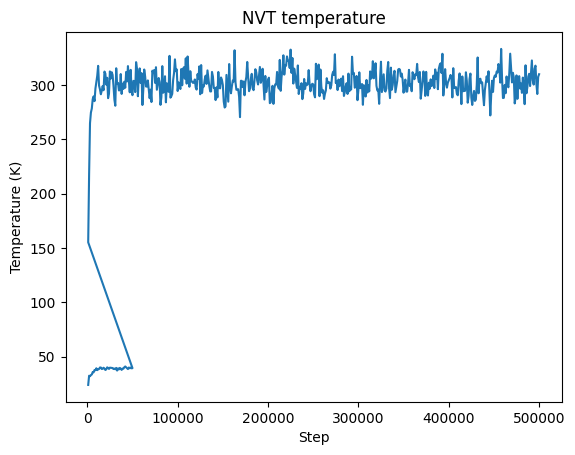

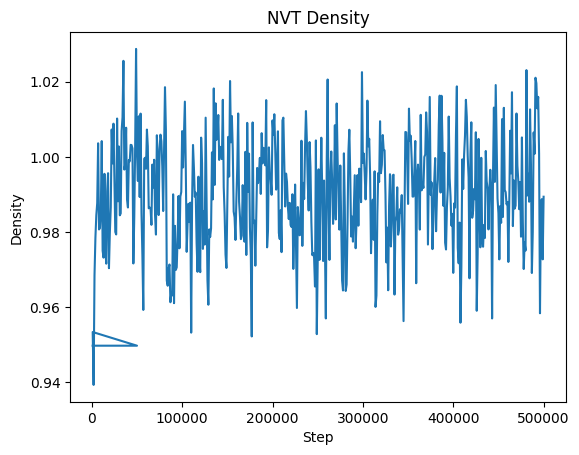

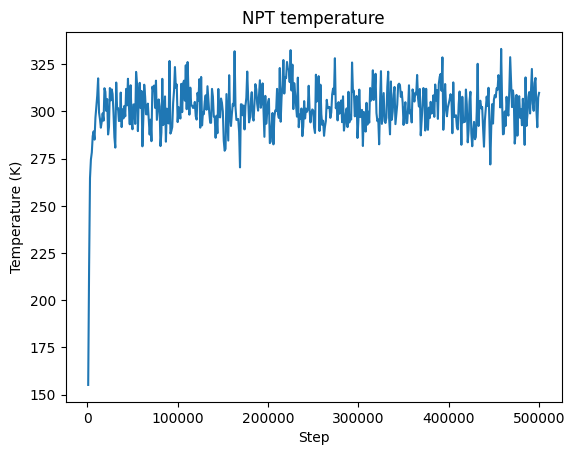

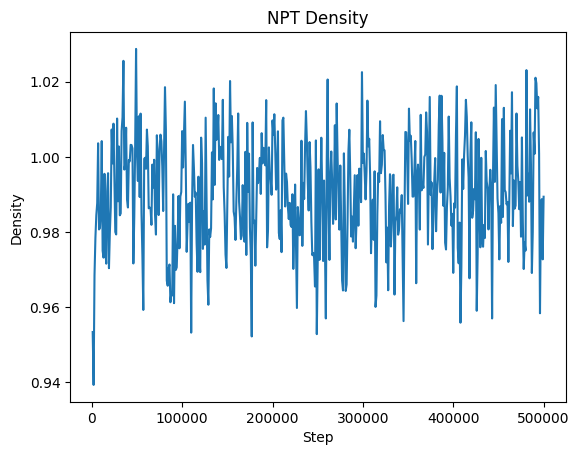

/usr/local/lib/python3.12/dist-packages/MDAnalysis/topology/PDBParser.py:372: UserWarning: Unknown element EP found for some atoms. These have been given an empty element record. If needed they can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn(wmsg)
/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


NoDataError: Cannot assign donor-hydrogen pairs via topology as no bond information is present. Please either: load a topology file with bond information; use the guess_bonds() topology guesser; or set HydrogenBondAnalysis.donors_sel so that a distance cutoff can be used.

In [19]:
# Time for analysis!
import MDAnalysis as mda
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA # For Hbond analysis
import numpy as np
import matplotlib.pyplot as plt

NVTdata = np.loadtxt("NVTOutput.txt", delimiter=',')

step = NVTdata[:,0]
potential_energy_nvt = NVTdata[:,1]
temperature_nvt = NVTdata[:,2]
density_nvt = NVTdata[:,3]

# plt.plot(step, potential_energy_nvt)
# plt.xlabel("Step")
# plt.ylabel("Potential energy (kJ/mol)")
# plt.title('NVT potential energy')
# plt.show()
plt.plot(step, temperature_nvt)
plt.xlabel("Step")
plt.ylabel("Temperature (K)")
plt.title('NVT temperature')
plt.show()
plt.plot(step, density_nvt)
plt.xlabel("Step")
plt.ylabel("Density")
plt.title('NVT Density')
plt.show()

# Now the NPT
NPTdata = np.loadtxt("NPTOutput.txt", delimiter=',')
step = NPTdata[:,0]
potential_energy_npt = NPTdata[:,1]
temperature_npt = NPTdata[:,2]
density_npt = NPTdata[:,3]

plt.plot(step, temperature_npt)
plt.xlabel("Step")
plt.ylabel("Temperature (K)")
plt.title('NPT temperature')
plt.show()
plt.plot(step, density_npt)
plt.xlabel("Step")
plt.ylabel("Density")
plt.title('NPT Density')
plt.show()

# Load a topology and a trajectory
u = mda.Universe('EMoutput.pdb', 'NPToutput.dcd')

# 1. Manually specify the hydrogen-containing atom group
h_selection = "(name H1) and (name H2)"

# 2. Manually specify the acceptor atom group
acc_selection = "(name O)"

hbonds = HBA(universe=u, hydrogens_sel=h_selection, acceptors_sel=acc_selection)
hbonds.run()